In [4]:
import pandas as pd

# Load the processed training and test datasets
train_data = pd.read_csv("Data/Processed/train_processed.csv")
test_data = pd.read_csv("Data/Processed/test_processed.csv")

# Preview the data
print(train_data.head())
print(test_data.head())

       Time        V1        V2        V3        V4        V5        V6  \
0  1.413095  1.946747 -0.752526 -1.355130 -0.661630  1.502822  4.024933   
1  0.624644  2.035149 -0.048880 -3.058693  0.247945  2.943487  3.298697   
2 -1.129186 -0.991920  0.603193  0.711976 -0.992425 -0.825838  1.956261   
3  0.796203  2.285718 -1.500239 -0.747565 -1.668119 -1.394143 -0.350339   
4 -0.746606 -0.448747 -1.011440  0.115903 -3.454854  0.715771 -0.147490   

         V7        V8        V9  ...       V21       V22       V23       V24  \
0 -1.479661  1.139880  1.406819  ...  0.076197  0.297537  0.307915  0.690980   
1 -0.002192  0.674782  0.045826  ...  0.038628  0.228197  0.035542  0.707090   
2 -2.212603 -5.037523  0.000772  ... -2.798352  0.109526 -0.436530 -0.932803   
3 -1.427984  0.010010 -1.118447  ... -0.139670  0.077013  0.208310 -0.538236   
4  0.504347 -0.113817 -0.044782  ... -0.243245 -0.173298 -0.006692 -1.362383   

        V25       V26       V27       V28    Amount  Class  
0 -0.35

In [5]:
#logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Define features and target variable
X_train = train_data.drop(columns=['Class'])
y_train = train_data['Class']

# Initialize logistic regression model
logistic_model = LogisticRegression()

# Train the model
logistic_model.fit(X_train, y_train)

# Define test features and target
X_test = test_data.drop(columns=['Class'])
y_test = test_data['Class']

# Make predictions
y_pred = logistic_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
# Print evaluation metrics
print(f"Accuracy: {accuracy}")
print("Classification Report:\n", class_report)
print("Confusion Matrix:\n", conf_matrix)   

/Users/huzaifamahmood/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/huzaifamahmood/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/huzaifamahmood/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/huzaifamahmood/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/huzaifamahmood/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:

Accuracy: 0.9742635441171307
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

Confusion Matrix:
 [[55406  1458]
 [    8    90]]


/Users/huzaifamahmood/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/huzaifamahmood/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/huzaifamahmood/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [6]:
#random forest
from sklearn.ensemble import RandomForestClassifier
# Define features and target variable for random forest
X_train_rf = train_data.drop(columns=['Class'])
y_train_rf = train_data['Class']

# Initialize random forest model
rf_model = RandomForestClassifier()

# Train the model
rf_model.fit(X_train_rf, y_train_rf)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# Print evaluation metrics
print(f"Accuracy: {accuracy_rf}")
print("Classification Report:\n", class_report_rf)
print("Confusion Matrix:\n", conf_matrix_rf)

Accuracy: 0.999403110845827
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.81      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
 [[56849    15]
 [   19    79]]


In [7]:
#XGBoost
from xgboost import XGBClassifier
# Define features and target variable for XGBoost
X_train_xgb = train_data.drop(columns=['Class'])
y_train_xgb = train_data['Class']
# Initialize XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
# Train the model
xgb_model.fit(X_train_xgb, y_train_xgb)
# Make predictions
y_pred_xgb = xgb_model.predict(X_test)
# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
class_report_xgb = classification_report(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

# Print evaluation metrics
print(f"Accuracy: {accuracy_xgb}")
print("Classification Report:\n", class_report_xgb)
print("Confusion Matrix:\n", conf_matrix_xgb)


/Users/huzaifamahmood/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [14:10:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.9992451107756047
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
 [[56832    32]
 [   11    87]]


/var/folders/sy/vptgh1ln55ggff5yxg_t7tmm0000gn/T/ipykernel_39597/2741092705.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')


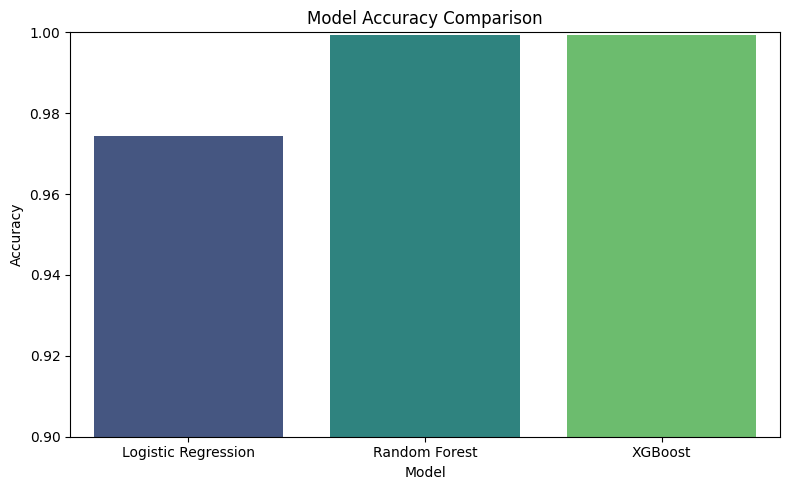

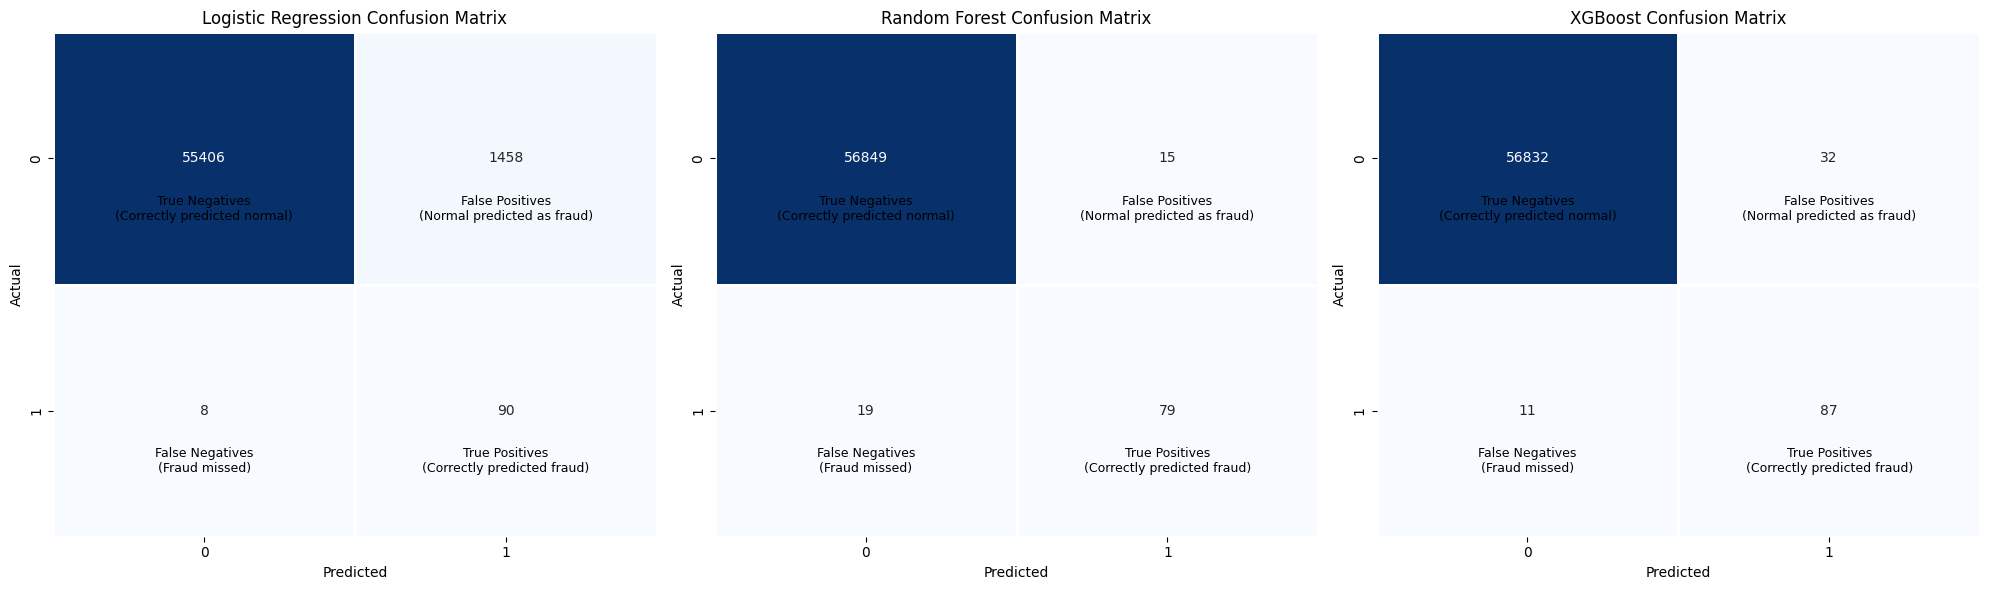

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for model accuracies
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy, accuracy_rf, accuracy_xgb]
})

# Bar chart for accuracy
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0.9, 1.0)
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.tight_layout()
plt.show()

# Confusion matrix heatmap for each model with explanations
labels = [["True Negatives\n(Correctly predicted normal)",
           "False Positives\n(Normal predicted as fraud)"],
          ["False Negatives\n(Fraud missed)",
           "True Positives\n(Correctly predicted fraud)"]]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, matrix, title in zip(
    axes,
    [conf_matrix, conf_matrix_rf, conf_matrix_xgb],
    ['Logistic Regression', 'Random Forest', 'XGBoost']
):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, linewidths=1)
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    # Add explanation labels
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.7, labels[i][j], fontsize=9, color='black', ha='center', va='center')
plt.tight_layout()
plt.show()